In [1]:
# load and save model and artifacts

import json
import joblib
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import matplotlib.pyplot as plt
import re

BASE_DIR = Path(".")
MODEL_DIR = BASE_DIR / "models" / "bert_9classes_final"
PROCESSED_DIR = Path("..") / "data" / "processed"

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR.resolve()), local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR.resolve()), local_files_only=True)

le = joblib.load(MODEL_DIR / "label_encoder.joblib")
num_labels = len(le.classes_)

with open(MODEL_DIR / "label_mapping.json", "r", encoding="utf-8") as f:
    mapping_data = json.load(f)
id2label = {int(k): v for k, v in mapping_data["id2label"].items()}

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Model loaded. Device: {device}")

/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1407.97it/s, Materializing param=classifier.weight]                                      


Model loaded. Device: mps


In [2]:
# load test data with predictions

from datasets import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

df_test = pd.read_csv(PROCESSED_DIR / "test.csv")
mapping_df = pd.read_csv(PROCESSED_DIR / "label_to_supercategory_v1.csv")
label_to_supercat = dict(zip(mapping_df["label"], mapping_df["supercategory"]))
df_test["supercategory"] = df_test["label"].map(label_to_supercat)
df_test["y_true"] = le.transform(df_test["supercategory"])

def tokenize_fn(batch):
    return tokenizer(batch["resume_text"], padding="max_length", truncation=True, max_length=128)

test_dataset = Dataset.from_pandas(df_test[["resume_text", "y_true"]])
test_dataset = test_dataset.map(tokenize_fn, batched=True)
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "y_true"])

dataloader = DataLoader(test_dataset, batch_size=32)
all_preds = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)

df_test["y_pred"] = all_preds
df_test["correct"] = df_test["y_true"] == df_test["y_pred"]
print(f"Test samples: {len(df_test)}, Accuracy: {df_test['correct'].mean():.4f}")

Inference: 100%|██████████| 173/173 [03:01<00:00,  1.05s/it]

Test samples: 5510, Accuracy: 0.6085


In [3]:
# IG setup
from captum.attr import LayerIntegratedGradients

def forward_func(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(forward_func, model.bert.embeddings)
print("IG initialized.")

IG initialized.


In [4]:
# helper functions

def compute_ig(text, target_class, n_steps=25):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding="max_length")
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    attributions = lig.attribute(inputs=input_ids, additional_forward_args=(attention_mask,), target=int(target_class), n_steps=n_steps)
    scores = attributions.sum(dim=-1).squeeze().detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    attention = attention_mask[0].cpu().numpy()
    return [(tok, score) for tok, score, att in zip(tokens, scores, attention) if att == 1]

def merge_wordpieces(token_scores):
    merged = []
    current_word, current_score = "", 0.0
    for tok, score in token_scores:
        if tok.startswith("##"):
            current_word += tok[2:]
            current_score += score
        else:
            if current_word: merged.append((current_word, current_score))
            current_word, current_score = tok, score
    if current_word: merged.append((current_word, current_score))
    return merged

def clean_filter(word_scores, min_len=3):
    special = {"[CLS]", "[SEP]", "[PAD]", "[UNK]", "[MASK]"}
    year_re = re.compile(r"^\d{4}$")
    garbage_re = re.compile(r"^[\W\d_]+$")
    stops = {"the", "and", "for", "with", "from", "that", "this", "are", "was", "were", "have", "has", "been"}
    return [(w, s) for w, s in word_scores if w.upper() not in special and not year_re.match(w) and not garbage_re.match(w) and len(w) >= min_len and w.lower() not in stops]

def get_top_attr(text, target_class, top_k=10, n_steps=25):
    raw = compute_ig(text, target_class, n_steps)
    merged = merge_wordpieces(raw)
    cleaned = clean_filter(merged)
    return sorted(cleaned, key=lambda x: abs(x[1]), reverse=True)[:top_k]

def plot_bar(word_scores, title, ax):
    if not word_scores: return
    words = [w for w,_ in word_scores]
    scores = [s for _,s in word_scores]
    colors = ["#2ecc71" if s > 0 else "#e74c3c" for s in scores]
    y_pos = np.arange(len(words))
    ax.barh(y_pos, scores, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(x=0, color="black", lw=0.5)
    ax.set_title(title, fontsize=9, fontweight="bold")

print("Helpers ready.")

Helpers ready.


In [5]:
# original 5 examples
examples = []
frontend_c = le.transform(["web_frontend"])[0]
backend_c = le.transform(["backend_general_dev"])[0]
sysadmin_c = le.transform(["sysadmin_devops_network"])[0]

for df_filt, typ, true_c, pred_fn in [
    (df_test[(df_test["y_true"]==frontend_c) & df_test["correct"]], "correct", "web_frontend", lambda r: "web_frontend"),
    (df_test[(df_test["y_true"]==frontend_c) & ~df_test["correct"]], "incorrect", "web_frontend", lambda r: id2label[r["y_pred"]]),
    (df_test[(df_test["y_true"]==backend_c) & df_test["correct"]], "correct", "backend_general_dev", lambda r: "backend_general_dev"),
    (df_test[(df_test["y_true"]==sysadmin_c) & ~df_test["correct"]], "incorrect", "sysadmin_devops_network", lambda r: id2label[r["y_pred"]]),
]:
    if len(df_filt) > 0:
        r = df_filt.iloc[0]
        examples.append({"idx": df_filt.index[0], "type": typ, "true_class": true_c, "pred_class": pred_fn(r)})

minority = ["Новосибирск", "Казань", "Екатеринбург"]
bias_df = df_test[(df_test["city_group"].isin(minority)) & ~df_test["correct"]]
if len(bias_df) > 0:
    r = bias_df.iloc[0]
    examples.append({"idx": bias_df.index[0], "type": "bias", "true_class": id2label[r["y_true"]], "pred_class": id2label[r["y_pred"]], "city": r["city_group"]})

print(f"{len(examples)} initial examples")

5 initial examples


Original IG:   0%|          | 0/5 [00:00<?, ?it/s]

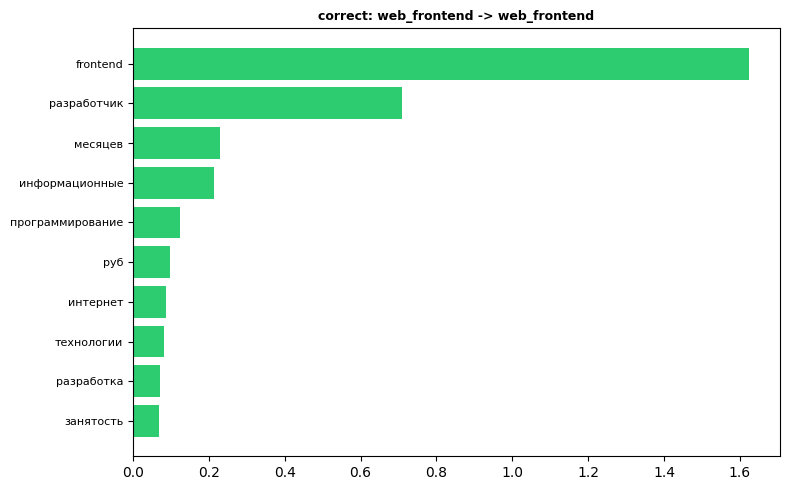

Original IG:  20%|██        | 1/5 [00:04<00:18,  4.73s/it]

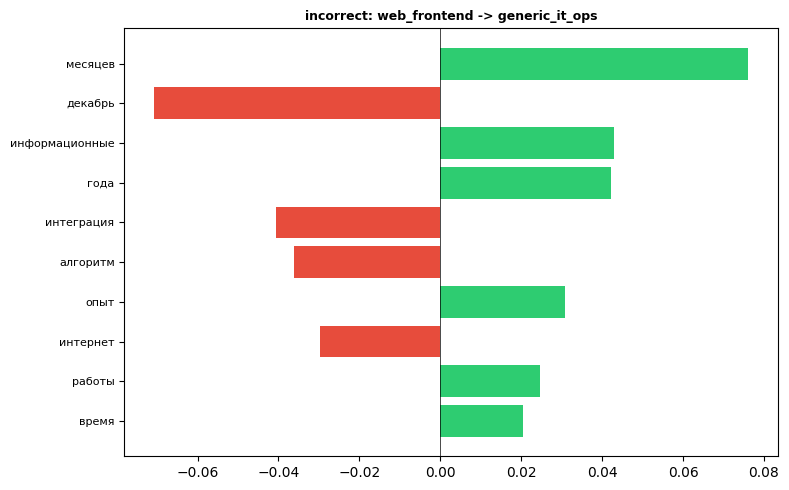

Original IG:  40%|████      | 2/5 [00:06<00:08,  2.81s/it]

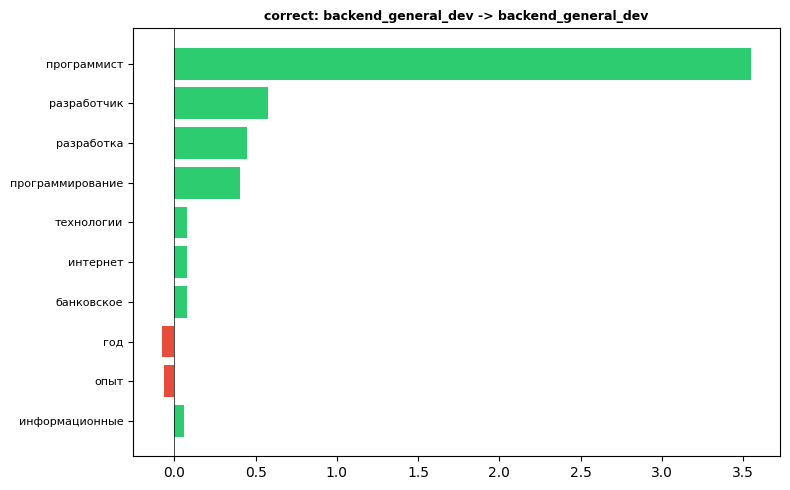

Original IG:  60%|██████    | 3/5 [00:07<00:04,  2.35s/it]

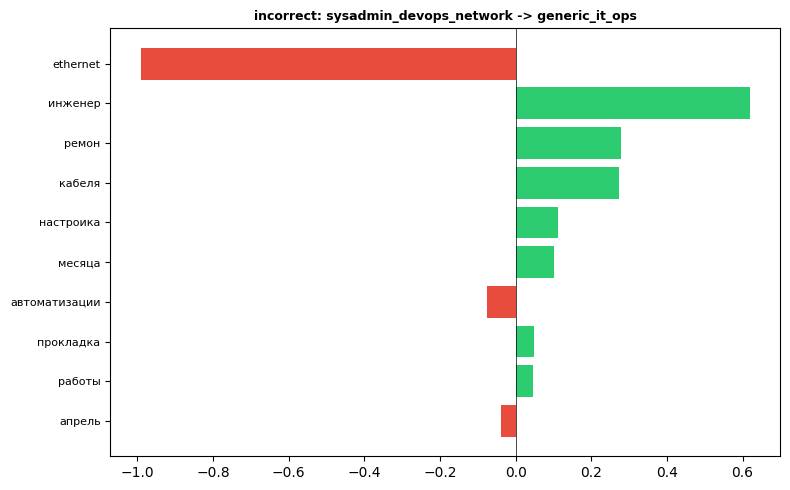

Original IG:  80%|████████  | 4/5 [00:09<00:02,  2.12s/it]

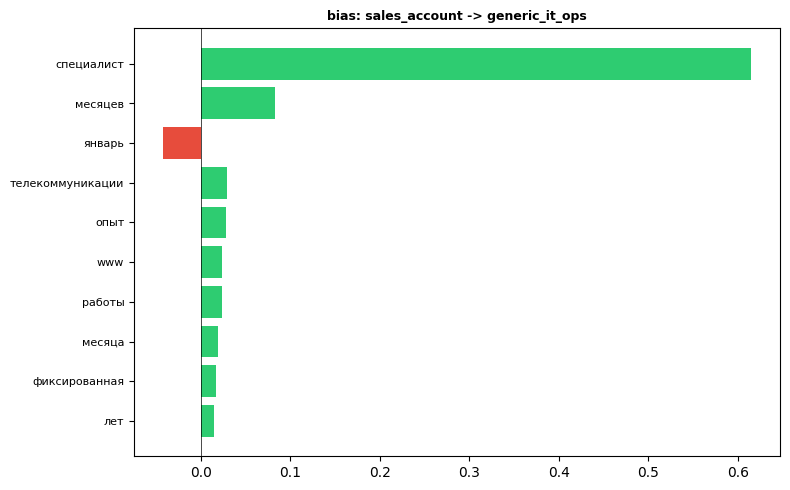

Original IG: 100%|██████████| 5/5 [00:11<00:00,  2.31s/it]


In [6]:
# analyze original 5
results = []
for ex in tqdm(examples, desc="Original IG"):
    row = df_test.loc[ex["idx"]]
    top_words = get_top_attr(row["resume_text"], row["y_pred"])
    results.append({"example": ex, "top_words": top_words})
    title = f"{ex['type']}: {ex['true_class']} -> {ex['pred_class']}"
    fig, ax = plt.subplots(figsize=(8,5))
    plot_bar(top_words, title, ax)
    plt.tight_layout()
    plt.show()

In [7]:
# save original summary
summary_rows = []
for r in results:
    ex = r["example"]
    pos = [w for w,s in r["top_words"] if s > 0][:5]
    neg = [w for w,s in r["top_words"] if s < 0][:5]
    summary_rows.append({"type": ex["type"], "true_class": ex["true_class"], "pred_class": ex["pred_class"], "top_positive": ", ".join(pos), "top_negative": ", ".join(neg)})
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("../figures/integrated_gradients_summary.csv", index=False)
summary_df

,type,true_class,pred_class,top_positive,top_negative
0,correct,web_frontend,web_frontend,"frontend, разработчик, месяцев, информационные...",
1,incorrect,web_frontend,generic_it_ops,"месяцев, информационные, года, опыт, работы","декабрь, интеграция, алгоритм, интернет"
2,correct,backend_general_dev,backend_general_dev,"программист, разработчик, разработка, программ...","год, опыт"
3,incorrect,sysadmin_devops_network,generic_it_ops,"инженер, ремон, кабеля, настроика, месяца","ethernet, автоматизации, апрель"
4,bias,sales_account,generic_it_ops,"специалист, месяцев, телекоммуникации, опыт, www",январь


In [8]:
# extended: 8 more examples for bias search
extra = []
used = {ex["idx"] for ex in examples}

searches = [
    ("small_city", df_test[(df_test["city_group"].isin(["Пермь","Воронеж","Красноярск","Омск"])) & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("moscow_ok", df_test[(df_test["city_group"]=="Москва") & df_test["correct"] & ~df_test.index.isin(used)]),
    ("other_city", df_test[(df_test["city_group"]=="Other") & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("support_err", df_test[(df_test["y_true"]==le.transform(["tech_support_helpdesk"])[0]) & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("pm_err", df_test[(df_test["y_true"]==le.transform(["project_product"])[0]) & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("sales_err", df_test[(df_test["y_true"]==le.transform(["sales_account"])[0]) & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("spb_err", df_test[(df_test["city_group"]=="Санкт-Петербург") & ~df_test["correct"] & ~df_test.index.isin(used)]),
    ("gov_err", df_test[(df_test["y_true"]==le.transform(["it_governance_leadership"])[0]) & ~df_test["correct"] & ~df_test.index.isin(used)]),
]

for name, df_filt in searches:
    if len(df_filt) > 0:
        r = df_filt.iloc[0]
        idx = df_filt.index[0]
        used.add(idx)
        city = r.get("city_group", "N/A") if "city" in name or name.endswith("_err") else None
        ex = {"idx": idx, "type": name, "true_class": id2label[r["y_true"]], "pred_class": id2label[r["y_pred"]]}
        if city: ex["city"] = city
        extra.append(ex)

print(f"Found {len(extra)} extra examples")

Found 8 extra examples


In [9]:
# compute IG for extra 8
extra_results = []
for ex in tqdm(extra, desc="Extra IG"):
    row = df_test.loc[ex["idx"]]
    top_words = get_top_attr(row["resume_text"], row["y_pred"])
    extra_results.append({"example": ex, "top_words": top_words})

Extra IG: 100%|██████████| 8/8 [00:16<00:00,  2.01s/it]


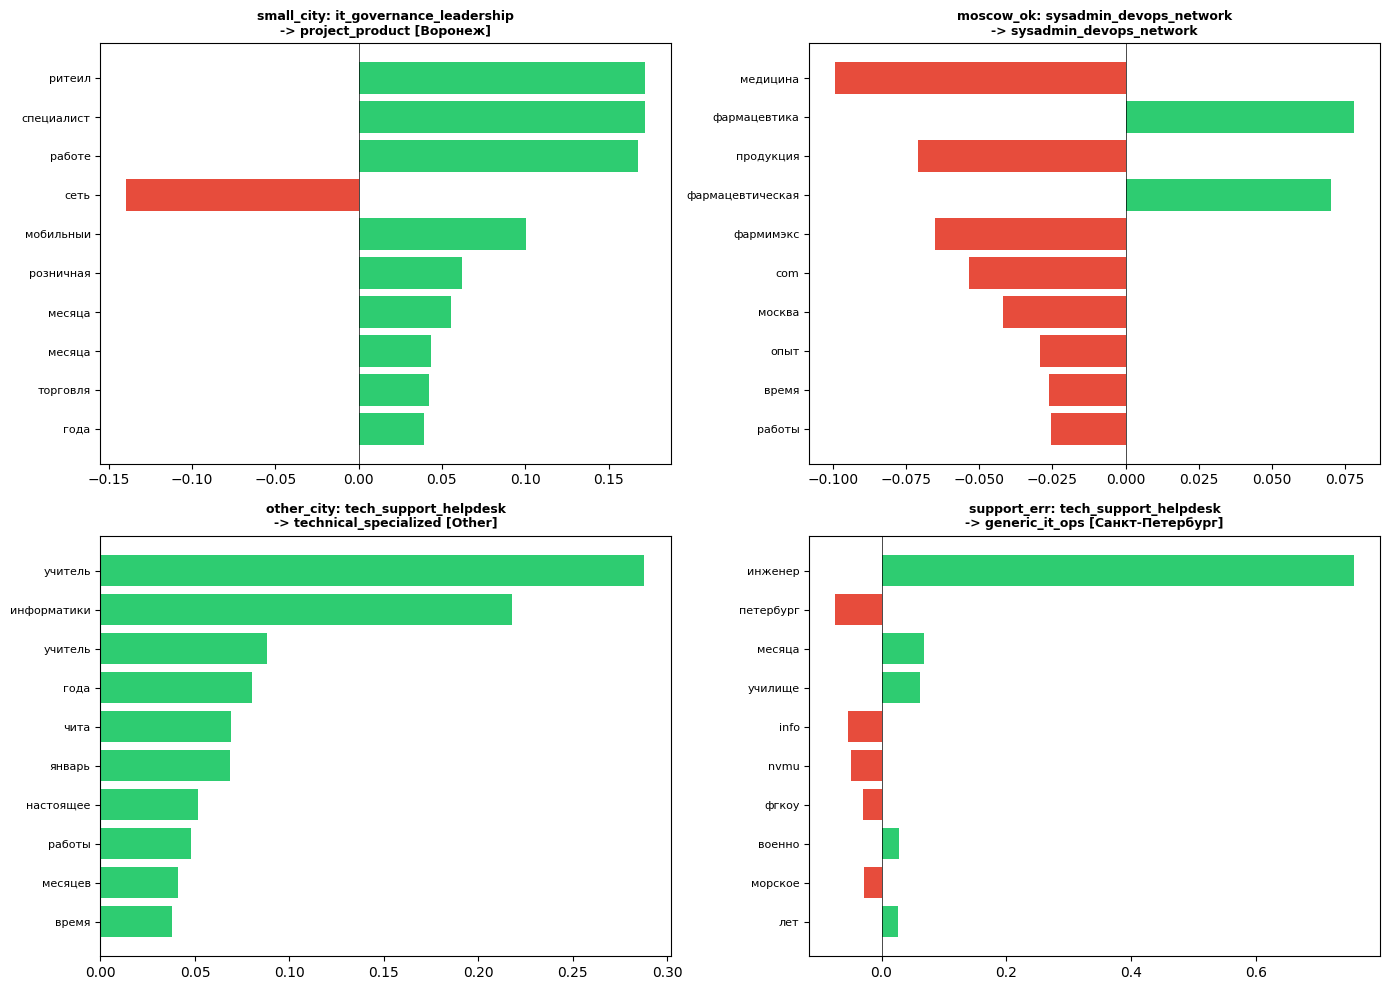

Saved ig_extra_grid1.png


In [10]:
# grid plot 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, r in enumerate(extra_results[:4]):
    ex = r["example"]
    city = f" [{ex.get('city','')}]" if 'city' in ex else ""
    title = f"{ex['type']}: {ex['true_class']}\n-> {ex['pred_class']}{city}"
    plot_bar(r["top_words"], title, axes[i])

plt.tight_layout()
plt.savefig("../figures/ig_extra_grid1.png", dpi=150)
plt.show()
print("Saved ig_extra_grid1.png")

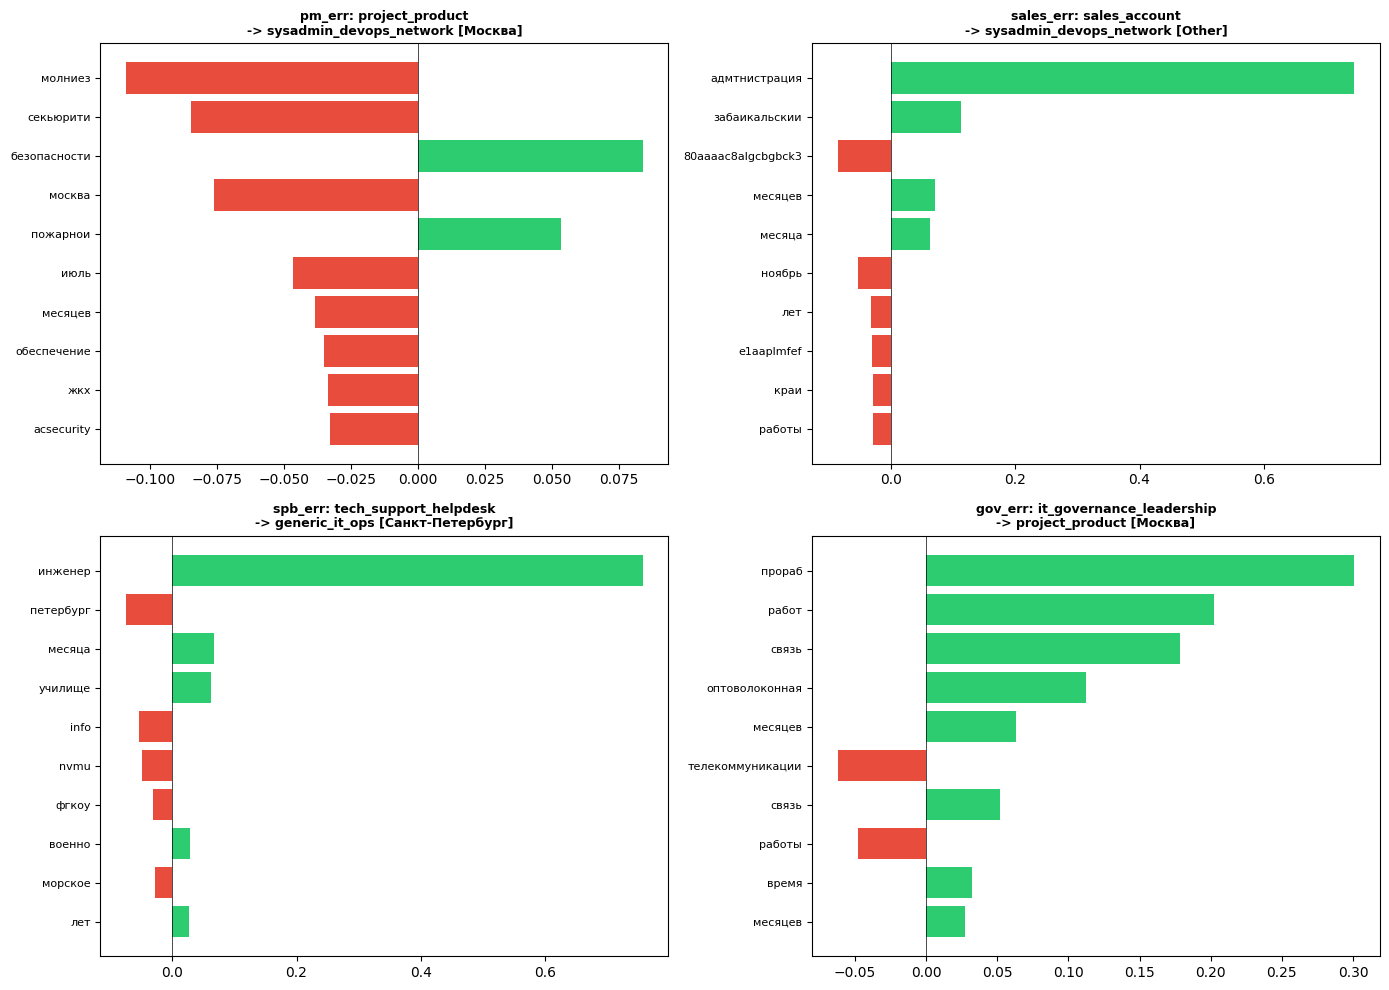

Saved ig_extra_grid2.png


In [11]:
# grid plot 2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, r in enumerate(extra_results[4:8]):
    ex = r["example"]
    city = f" [{ex.get('city','')}]" if 'city' in ex else ""
    title = f"{ex['type']}: {ex['true_class']}\n-> {ex['pred_class']}{city}"
    plot_bar(r["top_words"], title, axes[i])

plt.tight_layout()
plt.savefig("../figures/ig_extra_grid2.png", dpi=150)
plt.show()
print("Saved ig_extra_grid2.png")

In [12]:
# save extended summary
ext_rows = []
for r in extra_results:
    ex = r["example"]
    pos = [w for w,s in r["top_words"] if s > 0][:5]
    neg = [w for w,s in r["top_words"] if s < 0][:5]
    ext_rows.append({"type": ex["type"], "true_class": ex["true_class"], "pred_class": ex["pred_class"], "city": ex.get("city",""), "top_positive": ", ".join(pos), "top_negative": ", ".join(neg)})

ext_df = pd.DataFrame(ext_rows)
ext_df.to_csv("../figures/integrated_gradients_extended.csv", index=False)
print("Saved integrated_gradients_extended.csv")
ext_df

Saved integrated_gradients_extended.csv


,type,true_class,pred_class,city,top_positive,top_negative
0,small_city,it_governance_leadership,project_product,Воронеж,"ритеил, специалист, работе, мобильныи, розничная",сеть
1,moscow_ok,sysadmin_devops_network,sysadmin_devops_network,,"фармацевтика, фармацевтическая","медицина, продукция, фармимэкс, com, москва"
2,other_city,tech_support_helpdesk,technical_specialized,Other,"учитель, информатики, учитель, года, чита",
3,support_err,tech_support_helpdesk,generic_it_ops,Санкт-Петербург,"инженер, месяца, училище, военно, лет","петербург, info, nvmu, фгкоу, морское"
4,pm_err,project_product,sysadmin_devops_network,Москва,"безопасности, пожарнои","молниез, секьюрити, москва, июль, месяцев"
5,sales_err,sales_account,sysadmin_devops_network,Other,"адмтнистрация, забаикальскии, месяцев, месяца","80aaaac8algcbgbck3, ноябрь, лет, e1aaplmfef, краи"
6,spb_err,tech_support_helpdesk,generic_it_ops,Санкт-Петербург,"инженер, месяца, училище, военно, лет","петербург, info, nvmu, фгкоу, морское"
7,gov_err,it_governance_leadership,project_product,Москва,"прораб, работ, связь, оптоволоконная, месяцев","телекоммуникации, работы"
